<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn4cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # cifar 10은 총 10개의 레이블로 구성된 6만장(5만장:train, 1만장:test)의 컬러 이미지 dataset
# airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)   # (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)

print(x_train[0])
print(y_train[0])

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


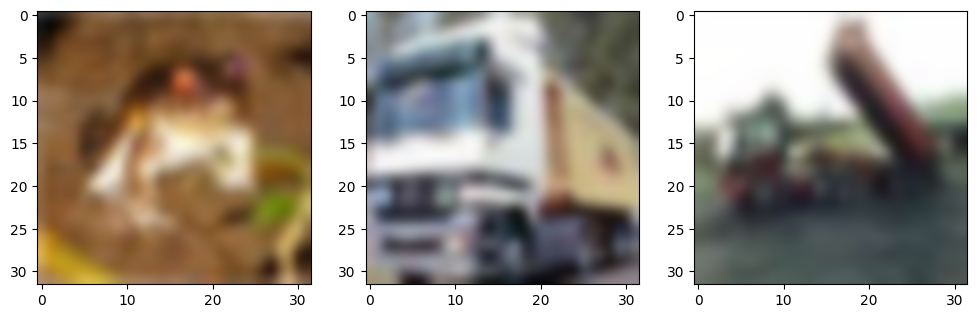

In [ ]:
# 시각화 : x_train[0]
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(x_train[0], interpolation='bicubic')
plt.subplot(132)
plt.imshow(x_train[1], interpolation='bicubic')
plt.subplot(133)
plt.imshow(x_train[2], interpolation='bicubic')
plt.show()

In [ ]:
# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Onehot encoding
NUM_CLASSES = 10
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)
print(y_train[0])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:
# model
# 실습 1 : Sequential API (CNN 없는 모델)
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=NUM_CLASSES, activation='softmax')
])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# 실습 1-1 : Functional API (CNN 없는 모델)
input_layer = Input(shape=(32, 32, 3))
x = Flatten()(input_layer)
x = Dense(units=256, activation='relu')(x)
x = Dense(units=128, activation='relu')(x)
output_layer = Dense(units=NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# 모델 컴파일, 학습
opti = Adam(learning_rate=0.001)
model.compile(optimizer=opti, loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train, y=y_train, batch_size=128, epochs=20, shuffle=True, verbose=2)

print('test acc : %.4f'%model.evaluate(x_test, y_test, verbose=0, batch_size=128)[1])
print('test loss : %.4f'%model.evaluate(x_test, y_test, verbose=0, batch_size=128)[0])

Epoch 1/20
391/391 - 5s - 13ms/step - accuracy: 0.3201 - loss: 1.8967
Epoch 2/20
391/391 - 1s - 3ms/step - accuracy: 0.3926 - loss: 1.6983
Epoch 3/20
391/391 - 1s - 3ms/step - accuracy: 0.4206 - loss: 1.6233
Epoch 4/20
391/391 - 1s - 3ms/step - accuracy: 0.4455 - loss: 1.5602
Epoch 5/20
391/391 - 1s - 3ms/step - accuracy: 0.4595 - loss: 1.5193
Epoch 6/20
391/391 - 1s - 3ms/step - accuracy: 0.4728 - loss: 1.4835
Epoch 7/20
391/391 - 1s - 3ms/step - accuracy: 0.4801 - loss: 1.4609
Epoch 8/20
391/391 - 1s - 3ms/step - accuracy: 0.4914 - loss: 1.4323
Epoch 9/20
391/391 - 2s - 4ms/step - accuracy: 0.5020 - loss: 1.4087
Epoch 10/20
391/391 - 2s - 4ms/step - accuracy: 0.5071 - loss: 1.3888
Epoch 11/20
391/391 - 1s - 3ms/step - accuracy: 0.5113 - loss: 1.3721
Epoch 12/20
391/391 - 1s - 3ms/step - accuracy: 0.5188 - loss: 1.3486
Epoch 13/20
391/391 - 1s - 3ms/step - accuracy: 0.5218 - loss: 1.3407
Epoch 14/20
391/391 - 1s - 3ms/step - accuracy: 0.5307 - loss: 1.3163
Epoch 15/20
391/391 - 1s - 3

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
예측값 : ['cat' 'ship' 'airplane' 'ship' 'deer' 'frog' 'cat' 'frog' 'bird'
 'automobile']
실제값 : ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 : 5


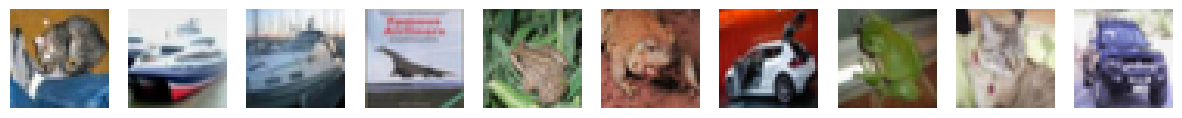

In [ ]:
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)]   # 0:열기준, 1:행기준, -1:행단위 뒤에서부터 처리
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]

print('예측값 :', pred)
print('실제값 :', actual)
print('분류 실패 수 :', (pred != actual).sum())

# 시각화
fig = plt.figure(figsize=(15, 3))
# fig.subplots_adjust(hspace=0.4, wspace=0.4)   # subplot 사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i + 1)
    ax.axis('off')
    ax.imshow(img)

    # transAxes : 이미지 픽셀 좌표 대신에 subplot 영역 기준 : 0.5 - 가운데 정렬, 0.0 - 왼쪽 정렬, 1.0 - 오른쪽 정렬
    ax.text(0.5, -0.35, 'pred=' + str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual=' + str(y_test[idx]), fontsize=10, ha='center', transform=ax.transAxes)

plt.show()

# 현재 모델은 컬러 이미지 분류에 대한 정확도가 떨어짐 (Dense만 사용)